<a href="https://colab.research.google.com/github/cluquezDS/ML2/blob/main/00_red_neuronal_make_moons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#1B2A4A 0%,#2C5F8A 100%); border-radius:14px; padding:40px 28px; margin:0 0 8px 0; text-align:center;">
<p style="margin:0 0 10px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12px; letter-spacing:3px; text-transform:uppercase; color:#9fc3de; font-weight:700;">Deep Learning</p>
<h1 style="margin:0 0 16px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:28px; line-height:1.35; color:#ffffff; font-weight:700;">Red Neuronal Multicapa para Clasificación No Lineal</h1>
<p style="margin:0 0 18px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:17px; color:#dceaf5; font-weight:700; letter-spacing:.3px; text-align:center;">Carolina Luque</p>
<p style="margin:0 auto; max-width:560px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.65; color:#c7d8e8;">Implementación desde cero, con NumPy, de una red neuronal multicapa (MLP) para resolver un problema de clasificación no lineal sobre el conjunto de datos <code>make_moons</code>.</p>
</div>

<div style="background:#EAF1F8; border-left:4px solid #2C5F8A; border-radius:0 10px 10px 0; padding:18px 22px; margin:24px 0;">
<p style="margin:0 0 8px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#2C5F8A;">Contexto del problema</p>
<p style="margin:0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.65; color:#1B2A4A;">El conjunto de datos <code>make_moons</code> genera dos clases entrelazadas en forma de lunas crecientes. Es imposible separarlas con una línea recta, por lo que necesitamos una frontera de decisión curva. La no linealidad (ReLU) combinada con la profundidad (2 capas ocultas) permite a la MLP aprender patrones complejos que un perceptrón simple nunca podría capturar. Esta es la esencia del poder del <strong>Deep Learning</strong>.</p>
</div>

<div style="background:#ffffff; border:1px solid #dbe6f0; border-radius:10px; padding:22px 26px; margin:24px 0;">
<p style="margin:0 0 14px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#2C5F8A;">Tabla de contenido</p>
<ol style="margin:0; padding-left:22px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:2; color:#1B2A4A;">
<li><a href="#seccion-1" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Preparación de Datos</a></li>
<li><a href="#seccion-2" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Funciones de Activación</a></li>
<li><a href="#seccion-3" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Implementación de la Red Neuronal Multicapa (MLP)</a></li>
<li><a href="#seccion-4" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Entrenamiento de la Red Neuronal</a></li>
<li><a href="#seccion-5" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Evaluación del Modelo</a></li>
<li><a href="#seccion-6" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Reto Práctico para Estudiantes</a></li>
<li><a href="#referencias" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Referencias</a></li>
</ol>
</div>

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Configuración para reproducibilidad
np.random.seed(42)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-1" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">1</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Preparación de Datos</span></span>

En esta sección, generaremos el conjunto de datos `make_moons`, lo visualizaremos, escalaremos sus características y lo dividiremos en conjuntos de entrenamiento y prueba.

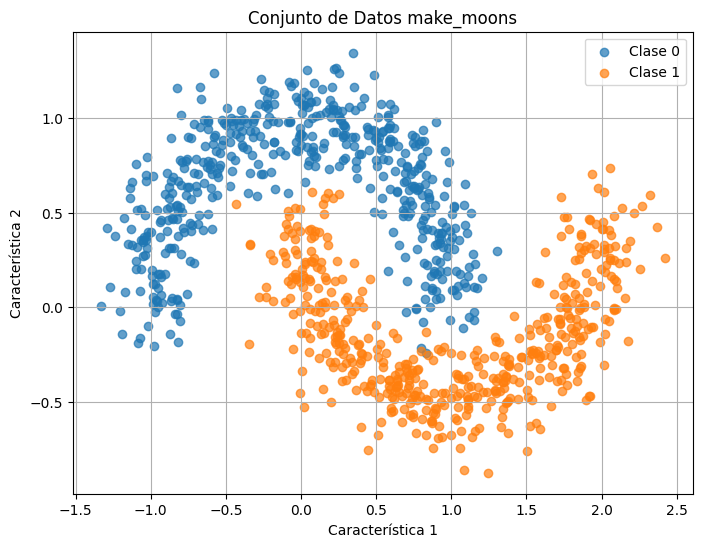

In [2]:
# Generación de datos
X, y = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Visualización de los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Clase 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1', alpha=0.7)
plt.title('Conjunto de Datos make_moons')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True)
plt.show()

# Escalado de características
scaler = StandardScaler()
X = scaler.fit_transform(X)

# División en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-2" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">2</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Funciones de Activación</span></span>

Definiremos las funciones de activación Sigmoide y ReLU, junto con sus respectivas derivadas, que serán utilizadas en nuestra red neuronal.

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500))) # np.clip para evitar overflow

def sigmoid_derivative(x):
    return x * (1 - x) # x se espera que sea la salida de la sigmoide

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float) # x se espera que sea la entrada a la relu (antes de la activación)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-3" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">3</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Implementación de la Red Neuronal Multicapa (MLP)</span></span>

<div style="text-align:center; margin:18px 0;">
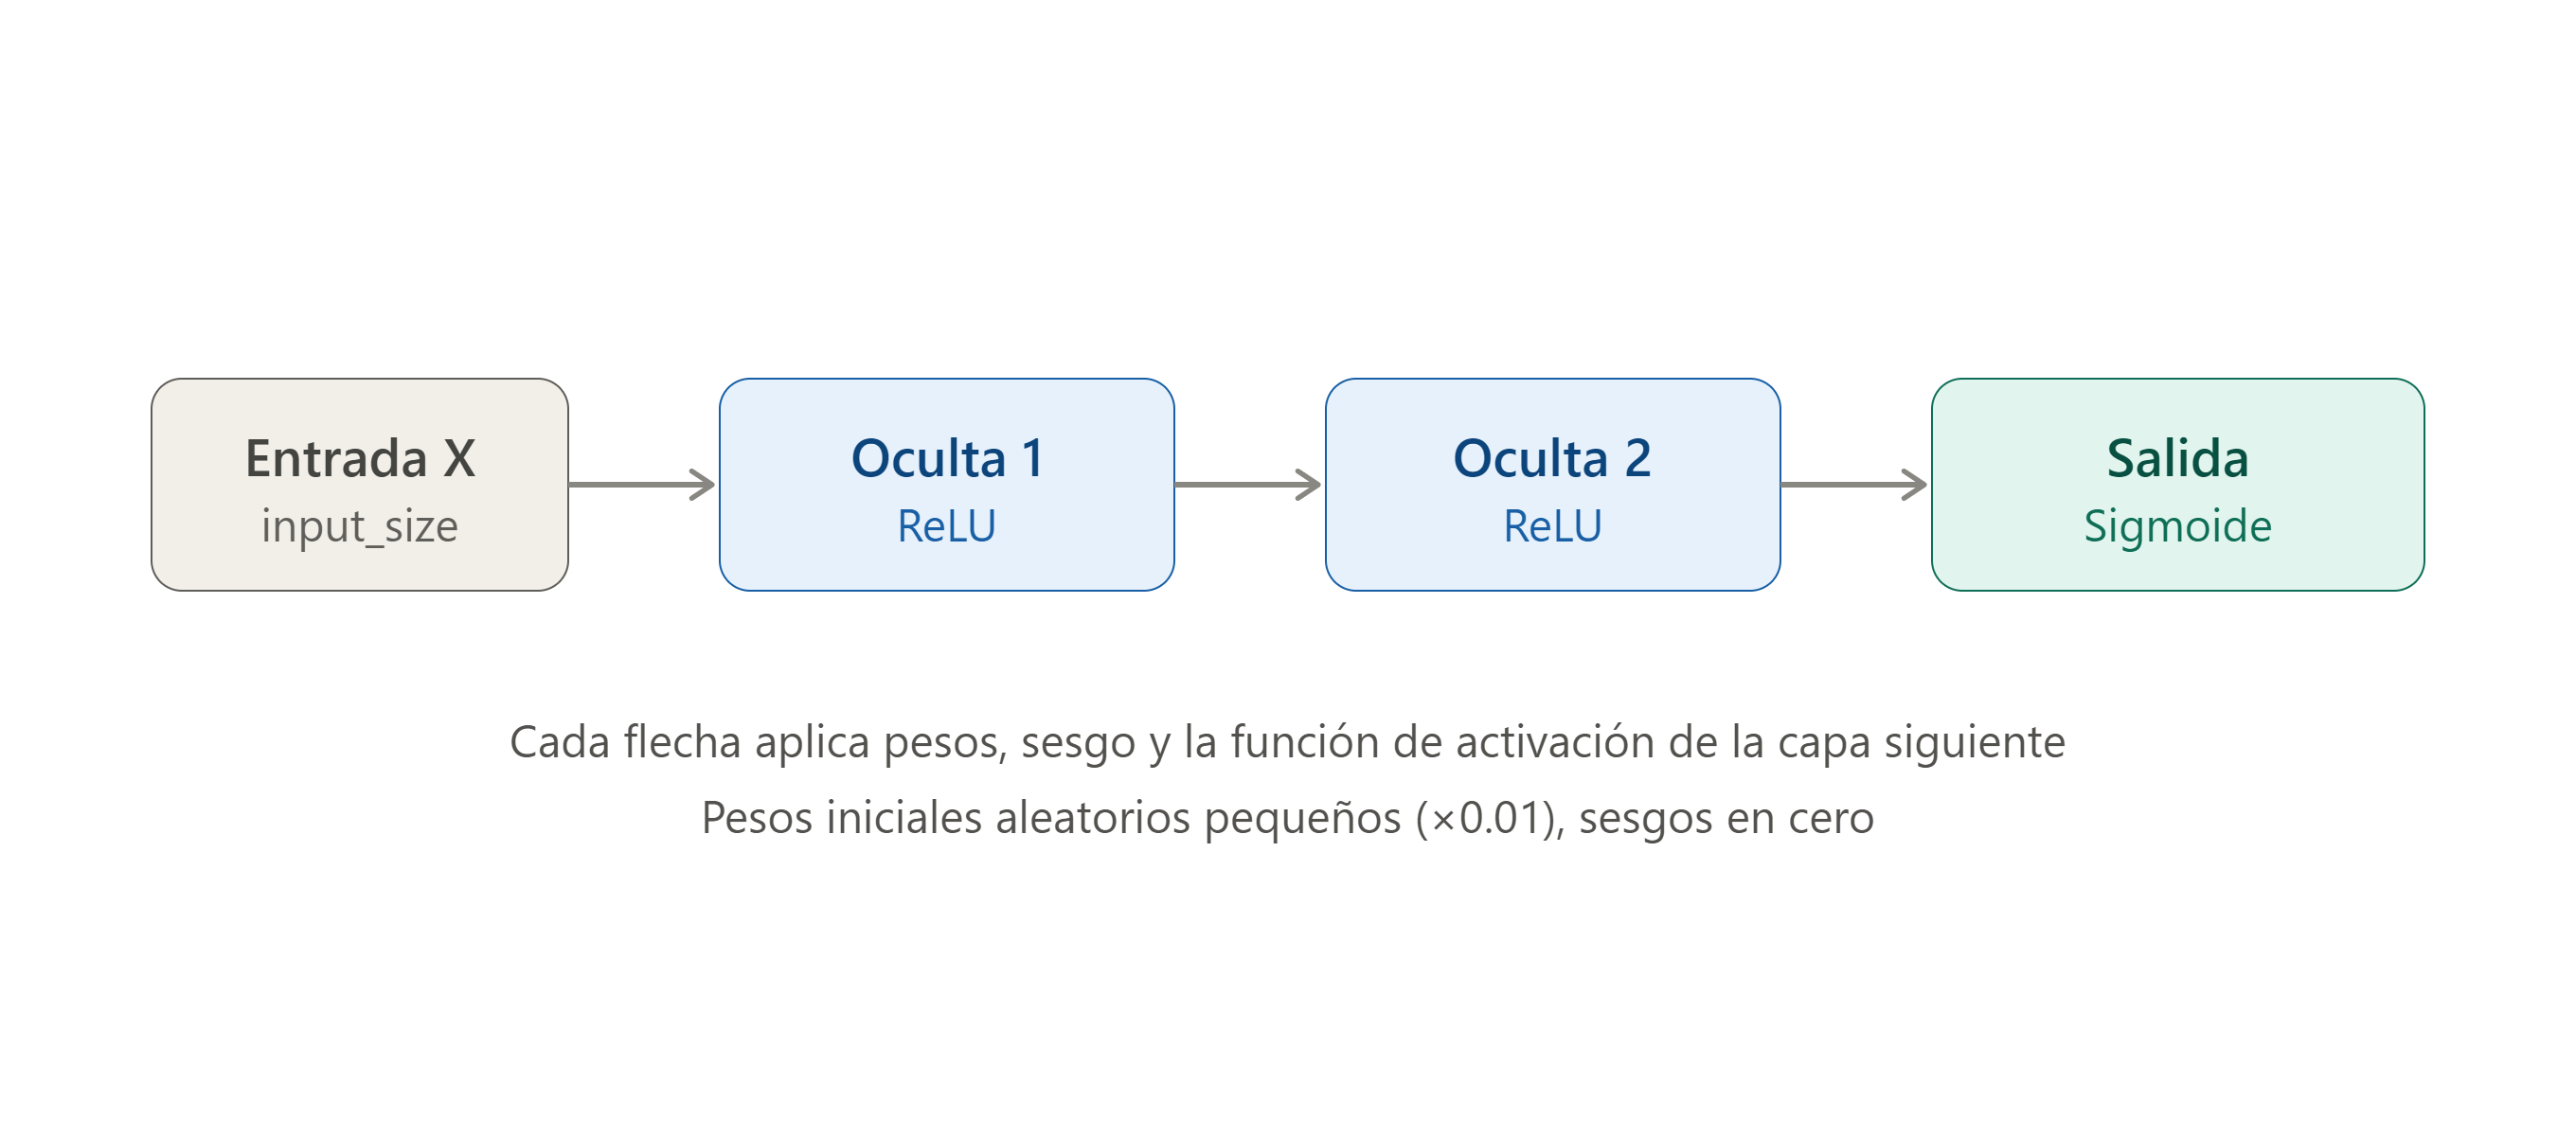
</div>

Aquí implementaremos la clase `NeuralNetwork` que representa nuestra MLP. Esta clase incluirá la arquitectura de dos capas ocultas con activación ReLU y una capa de salida con activación Sigmoide, tal como se especifica en el ejercicio. También incorporaremos la función de pérdida de entropía cruzada binaria y el optimizador Adam.

In [4]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        # Inicializa pesos y sesgos aleatoriamente
        self.weights_input_hidden1 = np.random.randn(input_size, hidden_size1) * 0.01
        self.bias_hidden1 = np.zeros((1, hidden_size1))
        self.weights_hidden1_hidden2 = np.random.randn(hidden_size1, hidden_size2) * 0.01
        self.bias_hidden2 = np.zeros((1, hidden_size2))
        self.weights_hidden2_output = np.random.randn(hidden_size2, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        # Parámetros para Adam (momentum y RMSprop)
        self.m_w1, self.v_w1 = np.zeros_like(self.weights_input_hidden1), np.zeros_like(self.weights_input_hidden1)
        self.m_b1, self.v_b1 = np.zeros_like(self.bias_hidden1), np.zeros_like(self.bias_hidden1)
        self.m_w2, self.v_w2 = np.zeros_like(self.weights_hidden1_hidden2), np.zeros_like(self.weights_hidden1_hidden2)
        self.m_b2, self.v_b2 = np.zeros_like(self.bias_hidden2), np.zeros_like(self.bias_hidden2)
        self.m_w3, self.v_w3 = np.zeros_like(self.weights_hidden2_output), np.zeros_like(self.weights_hidden2_output)
        self.m_b3, self.v_b3 = np.zeros_like(self.bias_output), np.zeros_like(self.bias_output)
        self.t = 0 # Contador de tiempo para Adam

    def forward(self, X):
        # Capa Oculta 1 (ReLU)
        self.hidden_layer1_input = np.dot(X, self.weights_input_hidden1) + self.bias_hidden1
        self.hidden_layer1_output = relu(self.hidden_layer1_input)

        # Capa Oculta 2 (ReLU)
        self.hidden_layer2_input = np.dot(self.hidden_layer1_output, self.weights_hidden1_hidden2) + self.bias_hidden2
        self.hidden_layer2_output = relu(self.hidden_layer2_input)

        # Capa de Salida (Sigmoide)
        self.output_layer_input = np.dot(self.hidden_layer2_output, self.weights_hidden2_output) + self.bias_output
        self.predicted_output = sigmoid(self.output_layer_input)
        return self.predicted_output

    def binary_cross_entropy(self, y_true, y_pred):
        # Evitar log(0) con np.clip
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def binary_cross_entropy_derivative(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        return (y_pred - y_true) / (y_pred * (1 - y_pred))

    def backward(self, X, y, predicted_output):
        y = y.reshape(-1, 1) # Asegurar que y tenga la forma correcta

        # Calcular el gradiente de la pérdida con respecto a la salida de la sigmoide
        d_loss_d_output = self.binary_cross_entropy_derivative(y, predicted_output)

        # Delta de la capa de salida
        delta_output_layer = d_loss_d_output * sigmoid_derivative(predicted_output)

        # Delta de la capa oculta 2
        error_hidden_layer2 = np.dot(delta_output_layer, self.weights_hidden2_output.T)
        delta_hidden_layer2 = error_hidden_layer2 * relu_derivative(self.hidden_layer2_input)

        # Delta de la capa oculta 1
        error_hidden_layer1 = np.dot(delta_hidden_layer2, self.weights_hidden1_hidden2.T)
        delta_hidden_layer1 = error_hidden_layer1 * relu_derivative(self.hidden_layer1_input)

        # Gradientes de los pesos y sesgos
        grads_w3 = np.dot(self.hidden_layer2_output.T, delta_output_layer)
        grads_b3 = np.sum(delta_output_layer, axis=0, keepdims=True)

        grads_w2 = np.dot(self.hidden_layer1_output.T, delta_hidden_layer2)
        grads_b2 = np.sum(delta_hidden_layer2, axis=0, keepdims=True)

        grads_w1 = np.dot(X.T, delta_hidden_layer1)
        grads_b1 = np.sum(delta_hidden_layer1, axis=0, keepdims=True)

        return grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3

    def update_params_adam(self, grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3):
        self.t += 1

        # Actualizar m y v para weights_input_hidden1
        self.m_w1 = self.beta1 * self.m_w1 + (1 - self.beta1) * grads_w1
        self.v_w1 = self.beta2 * self.v_w1 + (1 - self.beta2) * (grads_w1 ** 2)
        m_w1_corr = self.m_w1 / (1 - self.beta1 ** self.t)
        v_w1_corr = self.v_w1 / (1 - self.beta2 ** self.t)
        self.weights_input_hidden1 -= self.learning_rate * m_w1_corr / (np.sqrt(v_w1_corr) + self.epsilon)

        # Actualizar m y v para bias_hidden1
        self.m_b1 = self.beta1 * self.m_b1 + (1 - self.beta1) * grads_b1
        self.v_b1 = self.beta2 * self.v_b1 + (1 - self.beta2) * (grads_b1 ** 2)
        m_b1_corr = self.m_b1 / (1 - self.beta1 ** self.t)
        v_b1_corr = self.v_b1 / (1 - self.beta2 ** self.t)
        self.bias_hidden1 -= self.learning_rate * m_b1_corr / (np.sqrt(v_b1_corr) + self.epsilon)

        # Actualizar m y v para weights_hidden1_hidden2
        self.m_w2 = self.beta1 * self.m_w2 + (1 - self.beta1) * grads_w2
        self.v_w2 = self.beta2 * self.v_w2 + (1 - self.beta2) * (grads_w2 ** 2)
        m_w2_corr = self.m_w2 / (1 - self.beta1 ** self.t)
        v_w2_corr = self.v_w2 / (1 - self.beta2 ** self.t)
        self.weights_hidden1_hidden2 -= self.learning_rate * m_w2_corr / (np.sqrt(v_w2_corr) + self.epsilon)

        # Actualizar m y v para bias_hidden2
        self.m_b2 = self.beta1 * self.m_b2 + (1 - self.beta1) * grads_b2
        self.v_b2 = self.beta2 * self.v_b2 + (1 - self.beta2) * (grads_b2 ** 2)
        m_b2_corr = self.m_b2 / (1 - self.beta1 ** self.t)
        v_b2_corr = self.v_b2 / (1 - self.beta2 ** self.t)
        self.bias_hidden2 -= self.learning_rate * m_b2_corr / (np.sqrt(v_b2_corr) + self.epsilon)

        # Actualizar m y v para weights_hidden2_output
        self.m_w3 = self.beta1 * self.m_w3 + (1 - self.beta1) * grads_w3
        self.v_w3 = self.beta2 * self.v_w3 + (1 - self.beta2) * (grads_w3 ** 2)
        m_w3_corr = self.m_w3 / (1 - self.beta1 ** self.t)
        v_w3_corr = self.v_w3 / (1 - self.beta2 ** self.t)
        self.weights_hidden2_output -= self.learning_rate * m_w3_corr / (np.sqrt(v_w3_corr) + self.epsilon)

        # Actualizar m y v para bias_output
        self.m_b3 = self.beta1 * self.m_b3 + (1 - self.beta1) * grads_b3
        self.v_b3 = self.beta2 * self.v_b3 + (1 - self.beta2) * (grads_b3 ** 2)
        m_b3_corr = self.m_b3 / (1 - self.beta1 ** self.t)
        v_b3_corr = self.v_b3 / (1 - self.beta2 ** self.t)
        self.bias_output -= self.learning_rate * m_b3_corr / (np.sqrt(v_b3_corr) + self.epsilon)

    def train(self, X_train, y_train, epochs, batch_size=32, early_stopping_patience=10):
        losses = []
        best_loss = float('inf')
        patience_counter = 0

        num_samples = X_train.shape[0]
        for epoch in range(epochs):
            # Shuffle data for each epoch
            permutation = np.random.permutation(num_samples)
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]

            epoch_loss = 0
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                predicted_output = self.forward(X_batch)
                grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3 = self.backward(X_batch, y_batch, predicted_output)
                self.update_params_adam(grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3)
                epoch_loss += self.binary_cross_entropy(y_batch, predicted_output)

            avg_epoch_loss = epoch_loss / (num_samples / batch_size)
            losses.append(avg_epoch_loss)

            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}')

            # Early Stopping
            if avg_epoch_loss < best_loss:
                best_loss = avg_epoch_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f'Early stopping at epoch {epoch + 1} as loss did not improve for {early_stopping_patience} epochs.')
                    break

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-4" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">4</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Entrenamiento de la Red Neuronal</span></span>

Ahora, instanciamos y entrenamos nuestra red neuronal utilizando los parámetros especificados: 100 épocas, tamaño de lote de 32, optimizador Adam con una tasa de aprendizaje de 0.001 y early stopping.

Epoch 10/100, Loss: 0.9365
Early stopping at epoch 14 as loss did not improve for 10 epochs.


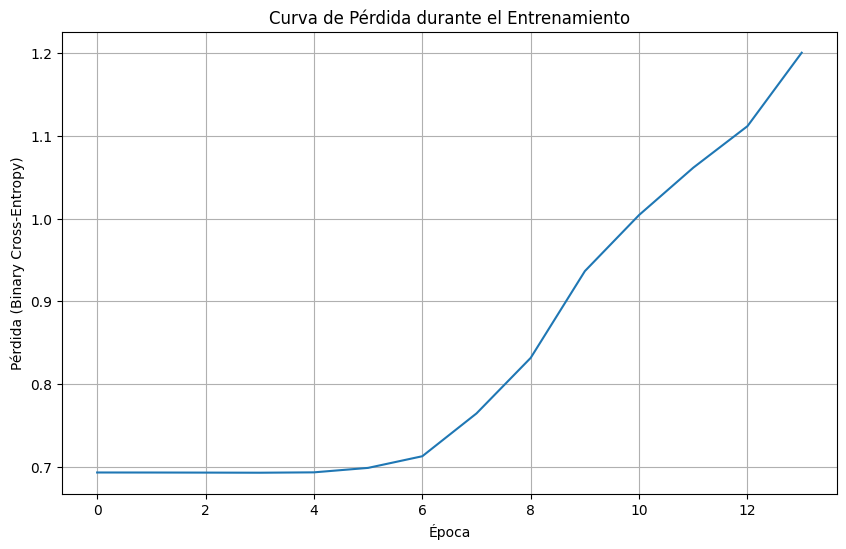

In [5]:
# Parámetros de la red
input_size = X_train.shape[1] # 2 características
hidden_size1 = 16
hidden_size2 = 8
output_size = 1
learning_rate = 0.001
epochs = 100
batch_size = 32
early_stopping_patience = 10

# Instanciar y entrenar la red neuronal
nn = NeuralNetwork(input_size, hidden_size1, hidden_size2, output_size, learning_rate=learning_rate)
losses = nn.train(X_train, y_train, epochs, batch_size, early_stopping_patience)

# Visualizar la curva de pérdida
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Cross-Entropy)')
plt.grid(True)
plt.show()

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-5" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">5</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Evaluación del Modelo</span></span>

Evaluaremos el rendimiento de nuestra red neuronal en el conjunto de prueba utilizando la métrica de `accuracy` y visualizaremos la frontera de decisión aprendida.

Precisión en el conjunto de prueba: 0.8550


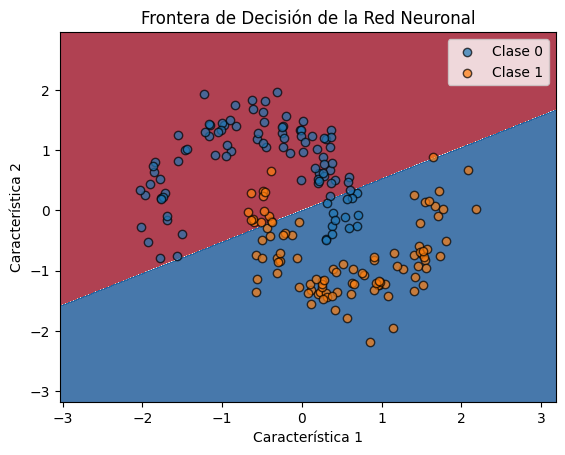

In [6]:
# Predicciones en el conjunto de prueba
y_pred_test = nn.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred_test)
print(f'Precisión en el conjunto de prueba: {accuracy:.4f}')

# Visualizar la frontera de decisión
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Clase 0', alpha=0.7, edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1', alpha=0.7, edgecolors='k')
    plt.title('Frontera de Decisión de la Red Neuronal')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.legend()
    plt.show()

plot_decision_boundary(nn, X_test, y_test)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-6" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">6</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Reto Práctico para Estudiantes</span></span>

¡Es tu turno de experimentar y mejorar! A continuación, se proponen algunos retos para que los estudiantes exploren y profundicen su comprensión de las redes neuronales.

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.1</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Experimentar con Hiperparámetros</span>
</div>

Modifica los siguientes hiperparámetros y observa cómo afectan el rendimiento del modelo (pérdida, precisión y frontera de decisión):

*   **Número de neuronas en las capas ocultas**: Prueba diferentes combinaciones, por ejemplo, (32, 16), (8, 4), (64, 32). ¿Cómo cambia la capacidad del modelo para aprender patrones complejos?
*   **Tasa de aprendizaje (`learning_rate`)**: Varía la tasa de aprendizaje (e.g., 0.1, 0.01, 0.0001). ¿Qué sucede si es demasiado alta o demasiado baja?
*   **Ruido en `make_moons`**: Cambia el parámetro `noise` al generar los datos (e.g., 0.05, 0.3). ¿Cómo afecta la dificultad del problema y el rendimiento del modelo?
*   **Épocas de entrenamiento**: Aumenta o disminuye el número de épocas. ¿Cuándo se produce el sobreajuste (overfitting) o el subajuste (underfitting)?
*   **Función de activación**: Reemplaza las funciones ReLU en las capas ocultas por Sigmoide o Tanh. ¿Qué impacto tiene en la capacidad de la red para aprender relaciones no lineales?

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.2</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Implementar Regularización</span>
</div>

Añade técnicas de regularización a la clase `NeuralNetwork` para prevenir el sobreajuste. Puedes considerar:

*   **Regularización L2 (Weight Decay)**: Añade un término de regularización L2 a la función de pérdida y a la actualización de los gradientes de los pesos.
*   **Dropout**: Implementa Dropout en las capas ocultas. ¿Cómo afecta la estabilidad del entrenamiento y la generalización del modelo?

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.3</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Clasificación Multiclase con <code>make_blobs</code></span>
</div>

Adapta la red neuronal para resolver un problema de clasificación multiclase. Utiliza el conjunto de datos `make_blobs` de `sklearn` con `n_features=2` y `centers=3` o más. Para esto, necesitarás:

*   Modificar la capa de salida para tener múltiples neuronas (una por clase) y usar la función de activación Softmax.
*   Cambiar la función de pérdida a Entropía Cruzada Categórica.
*   Ajustar la retropropagación para manejar la nueva función de pérdida y activación de salida.
*   Evaluar el modelo con métricas apropiadas para clasificación multiclase (e.g., `accuracy_score` y `classification_report` de `sklearn.metrics`).

<div style="background:#FBF0DC; border-left:4px solid #E9A84C; border-radius:0 8px 8px 0; padding:14px 18px; margin:22px 0 4px 0;">
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14px; color:#5c4315;"><strong style="color:#8a5a12;">¡Buena suerte con los retos! &#10022;</strong> Experimenta, equivócate y vuelve a intentarlo: así se aprende Deep Learning.</span>
</div>

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="referencias" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px;">Referencias</span>

<div style="background:#EAF1F8; border-radius:0 0 10px 10px; padding:16px 22px;">
<ol style="margin:0; padding-left:20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14px; line-height:1.9; color:#1B2A4A;">
<li>Goodfellow, I., Bengio, Y., &amp; Courville, A. (2016). <em>Deep Learning</em>. MIT Press. <a href="https://www.deeplearningbook.org/" style="color:#2C5F8A; font-weight:600;">deeplearningbook.org</a></li>
<li>Nielsen, M. (2015). <em>Neural Networks and Deep Learning</em>. <a href="http://neuralnetworksanddeeplearning.com/" style="color:#2C5F8A; font-weight:600;">neuralnetworksanddeeplearning.com</a></li>
<li>Kingma, D. P., &amp; Ba, J. (2014). <em>Adam: A Method for Stochastic Optimization</em>. arXiv:1412.6980. <a href="https://arxiv.org/abs/1412.6980" style="color:#2C5F8A; font-weight:600;">arxiv.org/abs/1412.6980</a></li>
</ol>
</div>

<div style="background:#1B2A4A; border-radius:10px; padding:20px; margin:28px 0 6px 0; text-align:center;">
<span style="color:#cfd7e6; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:13.5px; letter-spacing:.3px;">&copy; <strong style="color:#ffffff;">Carolina Luque</strong> &mdash; Deep Learning</span>
</div>